# Context: Precision Farming in Arid and Semi-arid Kenya

According to the Water Resources Management Authority (WRMA), an estimated 64% of water distributed in Kenya was allocated towards agricultural activities. Despite this, only 2% of arable land in Kenya is under irrigation compared to the average 6% in Africa and 37% in Asia. The low usage of irrigation means Kenya in fully dependant rainfall and is highly susceptible to drought shocks.

This poses a severe threat to the economy as agriculture accounts for 21.3% of GDP and 70% of employment in rural Kenya. 

As climate change accelerates, leading to more erratic rainfall patterns, Kenya should secure itself with robust irrigation infrastructre and transition to data-driven water management. 



## Project Scenario

This project aims to improve water efficiency for a smallholder farmer in Kenya by building a system that estimates soil-water balance, detects water stress, simulates uncertainty, and recommends irrigation decisions given soil and weather data.

## Data Overview

This data was collected periodically from sensors placed stategically across the farm and stored in the following files:

1. **Daily weather data**

    Contains daily synthetic weather data for 30 days.

    - Columns:  
      - `date`: day of observation
      - `rainfall_mm`: daily rainfall in millimeters
      - `temperature_c`: daily air temperature in Celsius
      - `humidity_pct`: relative humidity percentage
      - `wind_speed_mps`: wind speed in meters per second
      - `solar_index`: solar radiation index

In [7]:
import pandas as pd

weather_df = pd.read_csv("../data/raw/weather_daily.csv")
weather_df.head()

,date,rainfall_mm,temperature_c,humidity_pct,wind_speed_mps,solar_index
0,2026-03-01,3.2,23.8,69.7,2.28,0.78
1,2026-03-02,2.2,25.9,62.0,1.62,0.71
2,2026-03-03,3.0,26.8,64.4,2.11,0.75
3,2026-03-04,1.6,27.0,64.6,2.09,0.58
4,2026-03-05,23.7,26.6,61.0,1.36,0.62


2. **Soil sensor data** - Contains daily noon sensor readings for three farm zones.
    - Columns:
      - `timestamp`: timestamp of sensor reading
      - `zone_id`: zone identifier
      - `soil_moisture_pct`: soil moisture percentage
      - `tank_level_liters`: water tank level in liters
      - `pump_flow_lpm`: pump flow rate in liters per minute
      - `pump_power_watts`: pump power consumption in watts
      - `sensor_status`: sensor operational status

In [8]:
ssd_df = pd.read_csv("../data/raw/soil_sensor_data.csv")
ssd_df.head()

,timestamp,zone_id,soil_moisture_pct,tank_level_liters,pump_flow_lpm,pump_power_watts,sensor_status
0,2026-03-01 12:00,Zone_A,33.2,4829,18.8,437,OK
1,2026-03-01 12:00,Zone_B,34.7,4728,22.1,461,OK
2,2026-03-01 12:00,Zone_C,28.2,4515,25.7,490,OK
3,2026-03-02 12:00,Zone_A,36.1,4757,16.6,411,OK
4,2026-03-02 12:00,Zone_B,32.0,4645,20.4,445,OK



3. **Crop zone parameters** - Contains zone-level crop and soil-water parameters.
  
    - Columns:
      - `zone_id`: zone identifier
      - `crop_type`: crop grown in each zone
      - `area_m2`: zone area in square meters
      - `min_moisture_pct`: minimum soil moisture threshold
      - `target_moisture_pct`: target soil moisture level
      - `field_capacity_pct`: soil field capacity percentage
      - `drainage_coefficient`: zone-specific drainage coefficient

In [9]:
czp_df = pd.read_csv("../data/raw/crop_zone_parameters.csv")
czp_df.head()

,zone_id,crop_type,area_m2,min_moisture_pct,target_moisture_pct,field_capacity_pct,drainage_coefficient
0,Zone_A,tomato,120,22,33,41,0.18
1,Zone_B,kale,90,24,35,43,0.15
2,Zone_C,maize,180,20,31,40,0.22


## Data Dictionary

All variables used in HydroSense-Kenya are defined below.

### weather_daily.csv

| Variable | Unit | Description |
|---|---|---|
| `date` | YYYY-MM-DD | Calendar date of observation |
| `rainfall_mm` | mm | Total rainfall recorded for the day |
| `temperature_c` | °C | Mean daily air temperature |
| `humidity_pct` | % | Mean relative humidity (0–100) |
| `wind_speed_mps` | m/s | Mean wind speed at crop-canopy height |
| `solar_index` | dimensionless (0–1) | Normalised solar radiation index |

### soil_sensor_data.csv

| Variable | Unit | Description |
|---|---|---|
| `timestamp` | YYYY-MM-DD HH:MM | Date and time of noon sensor reading |
| `zone_id` | categorical | Farm zone identifier (Zone_A, Zone_B, Zone_C) |
| `soil_moisture_pct` | % | Volumetric soil moisture at sensor depth |
| `tank_level_liters` | L | Water remaining in the storage tank |
| `pump_flow_lpm` | L/min | Flow rate delivered by the irrigation pump |
| `pump_power_watts` | W | Electrical power consumed by the pump |
| `sensor_status` | categorical | Operational status flag (OK / FAULT / MISSING) |

### crop_zone_parameters.csv

| Variable | Unit | Description |
|---|---|---|
| `zone_id` | categorical | Farm zone identifier |
| `crop_type` | categorical | Crop grown in the zone (tomato, kale, maize) |
| `area_m2` | m² | Total cultivated area of the zone |
| `min_moisture_pct` | % | Minimum soil moisture before crop stress begins |
| `target_moisture_pct` | % | Optimal irrigation target moisture level |
| `field_capacity_pct` | % | Maximum moisture the soil can retain after drainage |
| `drainage_coefficient` | dimensionless (0–1) | Fraction of excess water lost to drainage per day |

### Computed / model variables

| Symbol | Unit | Description |
|---|---|---|
| `ET` | mm/day | Evapotranspiration — water lost from soil to atmosphere |
| `S_t` | % | Soil water storage (moisture) at time step *t* |
| `R_t` | mm | Rainfall contribution at time step *t* |
| `I_t` | mm | Irrigation applied at time step *t* |
| `D_t` | mm | Drainage loss at time step *t* |


## Core Python Functions

The two functions below are the computational foundation of HydroSense-Kenya.
They are written to be reusable across all later levels.


In [10]:
def compute_et(temperature_c, wind_speed_mps, solar_index, humidity_pct):
    """
    ET cannot be negative (clamped to 0 on cool, humid days).
    """
    et = 0.12 * temperature_c + 0.35 * wind_speed_mps + 2.4 * solar_index - 0.025 * humidity_pct
    return max(0.0, et)


def compute_water_balance(soil_moisture, rainfall_mm, irrigation_mm,
                          temperature_c, wind_speed_mps, solar_index,
                          humidity_pct, field_capacity_pct, drainage_coefficient):
    """
    
    Returns
    -------
    dict with keys:
        'et_mm'           – evapotranspiration computed for this day
        'drainage_mm'     – drainage loss computed for this day
        'new_soil_moisture' – updated soil moisture S_(t+1) (%)

    Assumptions
    -----------
    - Rainfall and irrigation are treated as equivalent soil-moisture inputs
      (no surface runoff or interception losses modelled at this level).
    - Soil moisture is bounded below at 0% (soil cannot be drier than bone dry).
    - Units of rainfall/irrigation (mm) are treated as directly equivalent to
      percentage-point changes in volumetric soil moisture, which is a
      simplification valid for instructional purposes.
    """
    et = compute_et(temperature_c, wind_speed_mps, solar_index, humidity_pct)

    # Drainage only when soil is above field capacity
    excess = max(0.0, soil_moisture - field_capacity_pct)
    drainage = drainage_coefficient * excess

    new_moisture = soil_moisture + rainfall_mm + irrigation_mm - et - drainage
    new_moisture = max(0.0, new_moisture)  # soil cannot go below 0 %

    return {
        'et_mm': round(et, 4),
        'drainage_mm': round(drainage, 4),
        'new_soil_moisture': round(new_moisture, 4)
    }


### Quick function verification

Run the functions on the first row of weather data and Zone A's parameters
to confirm they produce sensible outputs before we proceed.


In [11]:
import pandas as pd

weather_df = pd.read_csv("../data/raw/weather_daily.csv")
czp_df     = pd.read_csv("../data/raw/crop_zone_parameters.csv")
ssd_df     = pd.read_csv("../data/raw/soil_sensor_data.csv")

# Use Day 1 weather and Zone A parameters for the demo
day1    = weather_df.iloc[0]
zone_a  = czp_df[czp_df['zone_id'] == 'Zone_A'].iloc[0]
s0      = ssd_df[(ssd_df['zone_id'] == 'Zone_A')].iloc[0]['soil_moisture_pct']

et_day1 = compute_et(
    temperature_c  = day1['temperature_c'],
    wind_speed_mps = day1['wind_speed_mps'],
    solar_index    = day1['solar_index'],
    humidity_pct   = day1['humidity_pct']
)

wb_day1 = compute_water_balance(
    soil_moisture        = s0,
    rainfall_mm          = day1['rainfall_mm'],
    irrigation_mm        = 0.0,
    temperature_c        = day1['temperature_c'],
    wind_speed_mps       = day1['wind_speed_mps'],
    solar_index          = day1['solar_index'],
    humidity_pct         = day1['humidity_pct'],
    field_capacity_pct   = zone_a['field_capacity_pct'],
    drainage_coefficient = zone_a['drainage_coefficient']
)

print(f"Day 1 date            : {day1['date']}")
print(f"Initial soil moisture : {s0} %")
print(f"ET (mm/day)           : {et_day1}")
print(f"Water balance result  : {wb_day1['new_soil_moisture']}")


Day 1 date            : 2026-03-01
Initial soil moisture : 33.2 %
ET (mm/day)           : 3.7834999999999996
Water balance result  : 32.6165


## Basic Scientific Plot

The chart below shows daily rainfall alongside the computed ET for the 30-day
observation period. Days where ET exceeds rainfall indicate a water deficit —
the condition that drives the need for irrigation.


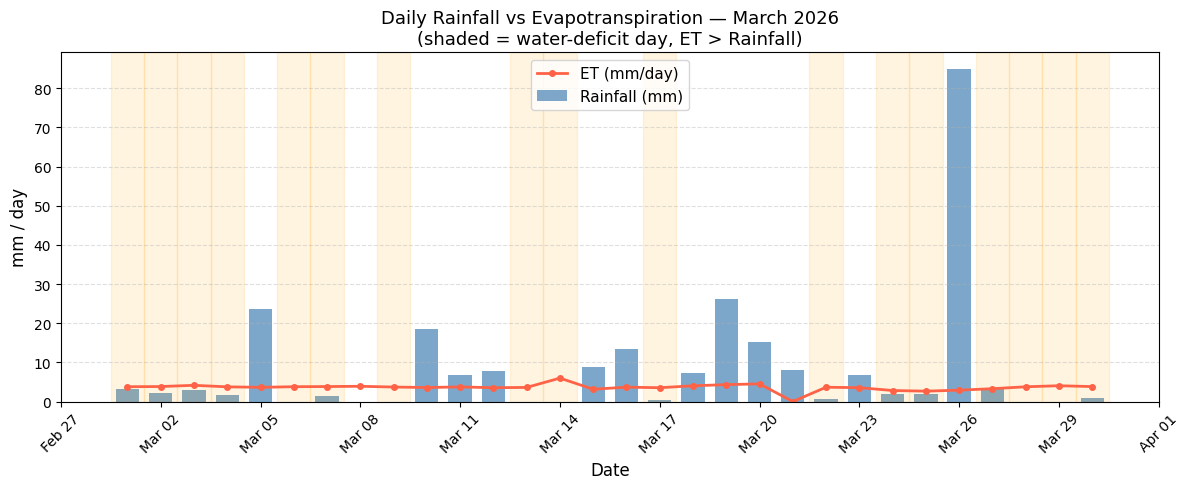

Deficit days: 17 / 30


In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

weather_df = pd.read_csv("../data/raw/weather_daily.csv", parse_dates=['date'])

# Compute daily ET for every row
weather_df['et_mm'] = weather_df.apply(
    lambda row: compute_et(
        row['temperature_c'], row['wind_speed_mps'],
        row['solar_index'],   row['humidity_pct']
    ), axis=1
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(weather_df['date'], weather_df['rainfall_mm'],
       color='steelblue', alpha=0.7, label='Rainfall (mm)', width=0.7)

ax.plot(weather_df['date'], weather_df['et_mm'],
        color='tomato', linewidth=2, marker='o', markersize=4, label='ET (mm/day)')

# Shade deficit days (ET > rainfall)
for _, row in weather_df.iterrows():
    if row['et_mm'] > row['rainfall_mm']:
        ax.axvspan(row['date'] - pd.Timedelta(hours=12),
                   row['date'] + pd.Timedelta(hours=12),
                   color='orange', alpha=0.12)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('mm / day', fontsize=12)
ax.set_title('Daily Rainfall vs Evapotranspiration — March 2026\n'
             '(shaded = water-deficit day, ET > Rainfall)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
#plt.savefig('../outputs/rainfall_vs_et_level1.png', dpi=150)
plt.show()
print(f"Deficit days: {(weather_df['et_mm'] > weather_df['rainfall_mm']).sum()} / {len(weather_df)}")


## Assumptions and Limitations of the Initial Model

### Assumptions

| # | Assumption | Justification |
|---|---|---|
| 1 | ET is estimated using a fixed empirical formula with four weather variables | Sufficient for instructional purposes; full FAO-56 Penman-Monteith requires additional data not available here |
| 2 | Rainfall and irrigation are treated as directly equivalent soil-moisture inputs (mm ≡ % point) | Simplifies the model for Level 1; a proper conversion would require soil bulk density and depth |
| 3 | No surface runoff or interception losses are modelled | Acceptable at small farm scale with low-intensity irrigation |
| 4 | Soil moisture cannot fall below 0 % (hard lower bound) | Physically correct; soils cannot hold negative water |
| 5 | Sensor readings taken at noon are representative of daily averages | Reasonable first approximation; diurnal variation is not modelled at this level |
| 6 | Crop water demand is uniform across each zone (no spatial variability within a zone) | Simplifies computation; spatial variability is a Level 5+ concern |

### Limitations

- **Simplified ET formula** — The empirical ET coefficients (0.12, 0.35, 2.4, 0.025) are fixed and were not calibrated against field measurements for the specific crops and soils on this farm. ET estimates will carry systematic error.
- **Unit mismatch** — Treating rainfall/irrigation in mm as equivalent to percentage-point changes in soil moisture is a known simplification. A rigorous model would apply a depth-and-bulk-density conversion factor.
- **No crop growth stage** — Crop water demand varies through the growing season (Kc curve). The current model applies a constant demand, which overestimates ET in early growth and underestimates it at peak.
- **No spatial resolution** — Each zone is treated as a single point. In reality, soil texture, slope, and canopy cover create moisture gradients within a zone.
- **30-day window** — The dataset covers a single month. Seasonal patterns, inter-annual variability, and the long-term water budget cannot be assessed.
- **Synthetic data** — The datasets are simulated, so model outputs cannot be directly validated against real field conditions at this stage.


## Problem Statement

Kenya's smallholder farmers operate under compounding pressures: unreliable rainfall, limited water infrastructure, and the accelerating effects of climate change on precipitation patterns. Agriculture contributes 21.3 % of GDP and employs 70 % of the rural workforce, yet only 2 % of arable land is under irrigation — far below the 6 % African average and 37 % global average. Without a shift toward data-driven water management, Kenyan farms remain highly exposed to drought shocks that directly threaten food security and livelihoods.

At the farm level, the core technical challenge is water balance uncertainty. A farmer must decide each morning whether to irrigate, how much to apply, and which zones to prioritise — but without computational tools, these decisions rely on intuition. Over-irrigation wastes water and energy and contributes to soil waterlogging and nutrient leaching. Under-irrigation causes crop moisture stress, yield loss, and in severe cases crop failure.

**HydroSense-Kenya** addresses this challenge by building a Python-based scientific computing system that translates daily weather observations and soil-sensor readings into actionable irrigation decisions. The system estimates soil-water balance using the discrete equation S_(t+1) = S_t + R_t + I_t − ET_t − D_t, where evapotranspiration is estimated from temperature, wind, solar radiation, and humidity. By tracking soil moisture relative to each crop zone's minimum threshold and field capacity, the system can detect imminent water stress and recommend the minimum irrigation volume needed to prevent it.

The central scientific question is: *Given weather and soil-sensor data from a Kenyan smallholder farm, how can we model daily water availability, estimate deficit, simulate future soil moisture under rainfall uncertainty, and recommend an efficient irrigation plan that minimises water use without exposing crops to moisture stress?*

This Level 1 notebook establishes the computational foundation — loading and inspecting the datasets, defining all variables in a data dictionary, implementing the ET and water-balance functions, and producing an initial visualisation of rainfall versus evaporative demand. These components will be extended with NumPy vectorisation, numerical methods, Monte Carlo simulation, and optimisation in Levels 2 through 6.
